<a href="https://colab.research.google.com/github/potopinc/colab/blob/main/ML_05_06_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Часть 1 (Занятие 5)

## Знакомимся с pandas

Библиотека **pandas** — библиотека для работы с данными, которая содержит высокоуровневые структуры данных и методы манипуляции ими.  
Сегодня pandas считается стандартом индустрии анализа данных.

Название pandas происходит от panel data — «панельные данные», что в эконометрике означает многомерные структуры данных.

Основу составляют две структуры данных:

Series;  
DataFrame.

In [1]:
import pandas as pd
from pandas import Series, DataFrame

# не забываем про импорт уже знакомых библиотек
import numpy as np
import matplotlib.pyplot as plt

### Series

**Тип данных Series**

Series — это объект данных, похожий на одномерный массив, который содержит набор значений и соответствующий им массив меток-индексов.

In [5]:
# создайте простой объект Series из списка значений
l = [1, 2, 3, 4, -5]
obj = Series(l)
obj

,0
0,1
1,2
2,3
3,4
4,-5


In [7]:
# получите представление самого массива с помощью атрибута values
obj.values

array([ 1,  2,  3,  4, -5])

In [8]:
# получите представление индексов с помощью атрибута index
obj.index

RangeIndex(start=0, stop=5, step=1)

In [10]:
# создайте "смысловые" индексы
obj.index = ['zero', 'one', 'two', 'three', 'four']
obj

,0
zero,1
one,2
two,3
three,4
four,-5


In [12]:
# ещё один способ создать Series
Series(l, index=['zero', 'one', 'two', 'three', 'four'])

,0
zero,1
one,2
two,3
three,4
four,-5


In [14]:
#Дан словарь: название архитектур нейронных сетей и их вес в мегабайтах. Создайте Series из словаря.

models = {
    "Xception": 88,
    "VGG16": 528,
    "ResNet50": 98,
    "InceptionV3": 92,
    "MobileNetV2": 14
}
obj_new = Series(models)
obj_new

,0
Xception,88
VGG16,528
ResNet50,98
InceptionV3,92
MobileNetV2,14


#### Доступ к элементам Series

In [17]:
# используйте доступ по нумерованному индексу
obj_new.iloc[3]

np.int64(92)

In [18]:
# используйте значение индекса для выборки элемента
obj_new['VGG16']

np.int64(528)

In [19]:
# используйте значение индекса для выборки элемента "через точку"
obj_new.VGG16

np.int64(528)

In [21]:
# используйте значения индекса для выборки нескольких элементов
obj_new['VGG16':'InceptionV3']

,0
VGG16,528
ResNet50,98
InceptionV3,92


In [22]:
# отфильтруйте массив с помощью логической операции (выберите модели с весом меньше 90)
obj_new[obj_new < 90]

,0
Xception,88
MobileNetV2,14


In [23]:
obj_new * 5

,0
Xception,440
VGG16,2640
ResNet50,490
InceptionV3,460
MobileNetV2,70


In [24]:
obj_new.value_counts()

,count
88,1
528,1
98,1
92,1
14,1


#### Основные функции
`obj.apply(len)` — применение функции к каждому элементу.

`obj.sum()` — сумма элементов.

`obj.any(func)` — первый подходящий элемент.

`obj = obj + 5` — добавить к каждому элементу 5.

`obj = obj * 5` — умножить каждый элемент на 5.

`obj.isin(list)` — есть ли элемент в списке?

`obj.mean()` — среднее значение.

`obj.astype(dtype)` — каждый элемент привести к типу.

`obj.value_counts()` — посчитать количество каждого элемента.

#### Практика 1

Выполни задание с использованием Series.

Создай объект models:
- индексы — названия моделей;
- значения — вес модели в мегабайтах.

Используй следующие данные:

`["Xception", "ResNet50", "MobileNetV2"]`, `[88, 98, 14]`




In [25]:
#1 твой код
obj = Series([88, 98, 14], index=["Xception", "ResNet50", "MobileNetV2"])
obj

,0
Xception,88
ResNet50,98
MobileNetV2,14


In [26]:
#2 посчитай суммарный вес моделей Xception и ResNet50
obj.sum()

np.int64(200)

In [29]:
#3 придумай название и добавьте еще одну модель: например, myNetV3 42
obj['myNetV3'] = 42
obj

,0
Xception,88.000000
ResNet50,120.222222
MobileNetV2,36.222222
myNetV3,42.000000


In [30]:
#4 для всех моделей, вес которых кратен 14, прибавь средний вес всех моделей, делённый на 3
obj[obj % 14 == 0] +=  round(((obj.sum() / 3) / 3), 2)
obj

,0
Xception,88.000000
ResNet50,120.222222
MobileNetV2,36.222222
myNetV3,73.830000


### DataFrame

**Тип данных DataFrame**

DataFrame — это набор Series.

Можно сказать, что это таблица, где каждая строка и каждый столбец — Series.

Доступ возможен как к строкам, так и к столбцам.

In [31]:
# создадим рандомный DataFrame

algorithms = ['Linear Regression', 'Random Forest', 'SVM', 'XGBoost', 'Neural Net', 'KNN']
task_types = ['Classification', 'Regression', 'Clustering']
data_types = ['Tabular', 'Text', 'Image']

# значение рандома
np.random.seed(8)

data = {
    'model': np.random.choice(algorithms, size=10),
    'type': np.random.choice(task_types, size=10),
    'score': np.random.randint(1, 10, size=10),
    'train_time': np.round(np.random.uniform(0.5, 10, size=10), 1),
    'data_size': np.random.randint(1000, 10000, size=10),
    'data_type': np.random.choice(data_types, size=10)
}

# создаем DataFrame
df = pd.DataFrame(data)
df

,model,type,score,train_time,data_size,data_type
0,XGBoost,Regression,3,9.8,1735,Tabular
1,Neural Net,Regression,3,1.7,2418,Text
2,Random Forest,Classification,7,3.6,9000,Image
3,Random Forest,Regression,9,1.2,2400,Image
4,KNN,Clustering,4,2.6,8771,Text
5,SVM,Classification,5,4.2,6483,Image
6,Linear Regression,Regression,6,9.0,2574,Image
7,XGBoost,Regression,6,3.8,6430,Image
8,Linear Regression,Regression,8,9.9,6166,Tabular
9,Linear Regression,Regression,3,0.8,4718,Text


In [33]:
# первые три строки
df.head(3)

,model,type,score,train_time,data_size,data_type
0,XGBoost,Regression,3,9.8,1735,Tabular
1,Neural Net,Regression,3,1.7,2418,Text
2,Random Forest,Classification,7,3.6,9000,Image


In [41]:
df.columns

Index(['model', 'type', 'score', 'train_time', 'data_size', 'data_type'], dtype='object')

In [35]:
# доступ к столбцам
df['model']

,model
0,XGBoost
1,Neural Net
2,Random Forest
3,Random Forest
4,KNN
5,SVM
6,Linear Regression
7,XGBoost
8,Linear Regression
9,Linear Regression


In [36]:
# еще доступ к столбцам
df['score']

,score
0,3
1,3
2,7
3,9
4,4
5,5
6,6
7,6
8,8
9,3


In [43]:
# доступ к строкам
df.iloc[4]

,4
model,KNN
type,Clustering
score,4
train_time,2.6
data_size,8771
data_type,Text


In [45]:
# выберите записи с помощью логических операций
df[(df['score'] < 5) & (df['type'] == 'Regression')]

,model,type,score,train_time,data_size,data_type
0,XGBoost,Regression,3,9.8,1735,Tabular
1,Neural Net,Regression,3,1.7,2418,Text
9,Linear Regression,Regression,3,0.8,4718,Text


In [46]:
# получите список имен столбцов
df.columns

Index(['model', 'type', 'score', 'train_time', 'data_size', 'data_type'], dtype='object')

In [49]:
# добавьте еще один столбец
df['one_more'] = 5
df

,model,type,score,train_time,data_size,data_type,one_more
0,XGBoost,Regression,3,9.8,1735,Tabular,5
1,Neural Net,Regression,3,1.7,2418,Text,5
2,Random Forest,Classification,7,3.6,9000,Image,5
3,Random Forest,Regression,9,1.2,2400,Image,5
4,KNN,Clustering,4,2.6,8771,Text,5
5,SVM,Classification,5,4.2,6483,Image,5
6,Linear Regression,Regression,6,9.0,2574,Image,5
7,XGBoost,Regression,6,3.8,6430,Image,5
8,Linear Regression,Regression,8,9.9,6166,Tabular,5
9,Linear Regression,Regression,3,0.8,4718,Text,5


In [52]:
# удалите этот столбец
df = df.drop(columns='one_more')
df

,model,type,score,train_time,data_size,data_type
0,XGBoost,Regression,3,9.8,1735,Tabular
1,Neural Net,Regression,3,1.7,2418,Text
2,Random Forest,Classification,7,3.6,9000,Image
3,Random Forest,Regression,9,1.2,2400,Image
4,KNN,Clustering,4,2.6,8771,Text
5,SVM,Classification,5,4.2,6483,Image
6,Linear Regression,Regression,6,9.0,2574,Image
7,XGBoost,Regression,6,3.8,6430,Image
8,Linear Regression,Regression,8,9.9,6166,Tabular
9,Linear Regression,Regression,3,0.8,4718,Text


#### Основные методы

`df.shape` — вывод количества строк и столбцов (кортеж).

`df.columns` — Index(количество стоблцов).

`df.info()` — общая информация о таблице.

`df.head(n)` — первые n строк (default — 5).

`df.tail(n)` — последние n строк (default — 5).


#### ПРАКТИКА 2
Выполни задание.

1. Добавь булевый столбец `окей`: `True`, если значение `score` больше 5 иначе `False`.
2. Выведи только те элементы, где значение столбца `окей` — `False`.
3. Поменяй название последнего стобца на `is_ok`.
4. Создай новый DataFrame `df_2`, в котором будут строки, у которых значения столбца `model` заканчивается буквой **t**. Для этого примени к столбцу конструнцию `.str`, после чего продолжай работать с ним как с обычной строкой.


In [57]:
# 1
df['okey'] = (df['score'] > 5)
df

,model,type,score,train_time,data_size,data_type,okey
0,XGBoost,Regression,3,9.8,1735,Tabular,False
1,Neural Net,Regression,3,1.7,2418,Text,False
2,Random Forest,Classification,7,3.6,9000,Image,True
3,Random Forest,Regression,9,1.2,2400,Image,True
4,KNN,Clustering,4,2.6,8771,Text,False
5,SVM,Classification,5,4.2,6483,Image,False
6,Linear Regression,Regression,6,9.0,2574,Image,True
7,XGBoost,Regression,6,3.8,6430,Image,True
8,Linear Regression,Regression,8,9.9,6166,Tabular,True
9,Linear Regression,Regression,3,0.8,4718,Text,False


In [58]:
# 2
df[df['okey'] == False]

,model,type,score,train_time,data_size,data_type,okey
0,XGBoost,Regression,3,9.8,1735,Tabular,False
1,Neural Net,Regression,3,1.7,2418,Text,False
4,KNN,Clustering,4,2.6,8771,Text,False
5,SVM,Classification,5,4.2,6483,Image,False
9,Linear Regression,Regression,3,0.8,4718,Text,False


In [60]:
# 3
df = df.rename(columns={'okey':'is_ok'})
df

,model,type,score,train_time,data_size,data_type,is_ok
0,XGBoost,Regression,3,9.8,1735,Tabular,False
1,Neural Net,Regression,3,1.7,2418,Text,False
2,Random Forest,Classification,7,3.6,9000,Image,True
3,Random Forest,Regression,9,1.2,2400,Image,True
4,KNN,Clustering,4,2.6,8771,Text,False
5,SVM,Classification,5,4.2,6483,Image,False
6,Linear Regression,Regression,6,9.0,2574,Image,True
7,XGBoost,Regression,6,3.8,6430,Image,True
8,Linear Regression,Regression,8,9.9,6166,Tabular,True
9,Linear Regression,Regression,3,0.8,4718,Text,False


In [61]:
# 4
df_2 = df[df['model'].str[-1] == 't']
df_2

,model,type,score,train_time,data_size,data_type,is_ok
0,XGBoost,Regression,3,9.8,1735,Tabular,False
1,Neural Net,Regression,3,1.7,2418,Text,False
2,Random Forest,Classification,7,3.6,9000,Image,True
3,Random Forest,Regression,9,1.2,2400,Image,True
7,XGBoost,Regression,6,3.8,6430,Image,True


#### Познакомьтесь с подвыборками DataFrame

Выполните ячейки кода с примерами ниже.

**Выбор одной строки**

In [62]:
df.iloc[0]

,0
model,XGBoost
type,Regression
score,3
train_time,9.8
data_size,1735
data_type,Tabular
is_ok,False


**Выбор нескольких подряд идущих строк**

In [63]:
df.iloc[1:4]

,model,type,score,train_time,data_size,data_type,is_ok
1,Neural Net,Regression,3,1.7,2418,Text,False
2,Random Forest,Classification,7,3.6,9000,Image,True
3,Random Forest,Regression,9,1.2,2400,Image,True


**Выбор нескольких строк**

In [64]:
df.iloc[[1,3,5]]

,model,type,score,train_time,data_size,data_type,is_ok
1,Neural Net,Regression,3,1.7,2418,Text,False
3,Random Forest,Regression,9,1.2,2400,Image,True
5,SVM,Classification,5,4.2,6483,Image,False


**Выбор одного стобца**

In [65]:
df['train_time']

,train_time
0,9.8
1,1.7
2,3.6
3,1.2
4,2.6
5,4.2
6,9.0
7,3.8
8,9.9
9,0.8


**Выбор нескольких подряд идущих столбцов**

In [68]:
# используем .loc и указываем выбор всех строк
df.loc[:, 'model':'score']

,model,type,score
0,XGBoost,Regression,3
1,Neural Net,Regression,3
2,Random Forest,Classification,7
3,Random Forest,Regression,9
4,KNN,Clustering,4
5,SVM,Classification,5
6,Linear Regression,Regression,6
7,XGBoost,Regression,6
8,Linear Regression,Regression,8
9,Linear Regression,Regression,3


In [69]:
df.loc[1:4, 'model':'score']

,model,type,score
1,Neural Net,Regression,3
2,Random Forest,Classification,7
3,Random Forest,Regression,9
4,KNN,Clustering,4


In [71]:
df.loc[1:6, ['model', 'score']]

,model,score
1,Neural Net,3
2,Random Forest,7
3,Random Forest,9
4,KNN,4
5,SVM,5
6,Linear Regression,6


**Выбор конкретных стобцов**

In [72]:
# используем двойные квадратные скобки
df[['model', 'score']]

,model,score
0,XGBoost,3
1,Neural Net,3
2,Random Forest,7
3,Random Forest,9
4,KNN,4
5,SVM,5
6,Linear Regression,6
7,XGBoost,6
8,Linear Regression,8
9,Linear Regression,3


**Выбор конкертных столбцов и нескольких подряд идущих строк**

In [73]:
# используем .loc, первым значение указываем срез строк, затем список нужных стобцов
df.loc[1:4, ['model','score']]

,model,score
1,Neural Net,3
2,Random Forest,7
3,Random Forest,9
4,KNN,4


**Выбор всех строк, которые подходят под условие**

In [74]:
df[df['type'] == 'Classification']

,model,type,score,train_time,data_size,data_type,is_ok
2,Random Forest,Classification,7,3.6,9000,Image,True
5,SVM,Classification,5,4.2,6483,Image,False


## Работа с файлами

Функция **read_csv** загружает в DataFrame данные из файла.

Несколько параметров этой функции:

`sep` задаёт разделитель столбцов. По умолчанию — запятая, но часто встречается точка с запятой.

`dtype` позволяет заранее указать типы данных для столбцов через словарь.

`encoding` указывает кодировку файла.

`index_col` — номер столбца или имя, который станет индексом.

In [80]:
df = pd.read_csv("steam_games.csv")
df.head(10)

,name,developers_1,category_1,category_2,genre_1,genre_2,n_achievements,platforms,is_released,release_date,total_reviews,total_positive,total_negative,review_score,metacritic,is_free,price_initial (USD)
0,勇者の伝説の勇者,ぽけそう,Single-player,Family Sharing,Casual,Indie,0.0,NaN,True,2024-01-04,0.0,0.0,0.0,0.0,0.0,NaN,0.99
1,Light No Fire,Hello Games,Single-player,Multi-player,Action,Adventure,0.0,NaN,False,Not Released,0.0,0.0,0.0,0.0,0.0,NaN,0.00
2,PUIQ: Demons,Giammnn,Single-player,Steam Achievements,Action,Casual,28.0,['windows'],True,2024-02-17,0.0,0.0,0.0,0.0,0.0,False,2.99
3,Project XSTING,Saucy Melon,Single-player,Steam Achievements,Action,Casual,42.0,['windows'],True,2024-01-05,9.0,9.0,0.0,0.0,0.0,False,7.99
4,The Milgram Experiment,Theseus Games,Single-player,-,Adventure,-,0.0,['windows'],False,Not Released,0.0,0.0,0.0,0.0,0.0,False,NaN
5,5 Bucks for the Bus,Frog Vibes,Single-player,Steam Achievements,Indie,RPG,0.0,['windows'],False,Not Released,0.0,0.0,0.0,0.0,0.0,False,NaN
6,Manor Madness,Apericot Studio,Single-player,Steam Achievements,Action,Adventure,5.0,"['windows', 'mac', 'linux']",True,2024-01-15,0.0,0.0,0.0,0.0,0.0,True,0.00
7,Fly Hands,Kuryakin,Single-player,Tracked Controller Support,Adventure,Casual,0.0,['windows'],True,2024-03-26,0.0,0.0,0.0,0.0,0.0,False,13.99
8,Zero Caliber 2,XREAL Games,Single-player,Multi-player,Action,-,0.0,['windows'],False,Not Released,0.0,0.0,0.0,0.0,0.0,False,NaN
9,Star Birds,Toukana Interactive,Single-player,Steam Achievements,Casual,Indie,0.0,['windows'],False,Not Released,0.0,0.0,0.0,0.0,0.0,False,NaN


In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69526 entries, 0 to 69525
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   name                 69526 non-null  object 
 1   developers_1         69520 non-null  object 
 2   category_1           69526 non-null  object 
 3   category_2           69526 non-null  object 
 4   genre_1              69526 non-null  object 
 5   genre_2              69526 non-null  object 
 6   n_achievements       69051 non-null  float64
 7   platforms            69069 non-null  object 
 8   is_released          69042 non-null  object 
 9   release_date         69062 non-null  object 
 10  total_reviews        69105 non-null  float64
 11  total_positive       69090 non-null  float64
 12  total_negative       69083 non-null  float64
 13  review_score         69076 non-null  float64
 14  metacritic           69079 non-null  float64
 15  is_free              69114 non-null 

In [81]:
df

,name,developers_1,category_1,category_2,genre_1,genre_2,n_achievements,platforms,is_released,release_date,total_reviews,total_positive,total_negative,review_score,metacritic,is_free,price_initial (USD)
0,勇者の伝説の勇者,ぽけそう,Single-player,Family Sharing,Casual,Indie,0.0,NaN,True,2024-01-04,0.0,0.0,0.0,0.0,0.0,NaN,0.99
1,Light No Fire,Hello Games,Single-player,Multi-player,Action,Adventure,0.0,NaN,False,Not Released,0.0,0.0,0.0,0.0,0.0,NaN,0.00
2,PUIQ: Demons,Giammnn,Single-player,Steam Achievements,Action,Casual,28.0,['windows'],True,2024-02-17,0.0,0.0,0.0,0.0,0.0,False,2.99
3,Project XSTING,Saucy Melon,Single-player,Steam Achievements,Action,Casual,42.0,['windows'],True,2024-01-05,9.0,9.0,0.0,0.0,0.0,False,7.99
4,The Milgram Experiment,Theseus Games,Single-player,-,Adventure,-,0.0,['windows'],False,Not Released,0.0,0.0,0.0,0.0,0.0,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69521,Touchdown Pinball,Super PowerUp Games,Single-player,Steam Achievements,Simulation,-,15.0,['windows'],True,2024-02-09 00:00:00,2.0,2.0,0.0,0.0,0.0,False,2.99
69522,Speed Golf Royale,Mainframe Games,Single-player,Multi-player,Action,Casual,0.0,['windows'],False,Not Released,0.0,0.0,0.0,0.0,0.0,False,NaN
69523,Isle of Swaps,Fuzz Force,Single-player,Steam Achievements,Indie,RPG,29.0,['windows'],True,2024-09-27 00:00:00,72.0,66.0,6.0,8.0,0.0,False,14.99
69524,Goobies,Knifes,Single-player,Steam Achievements,Action,Casual,43.0,['windows'],True,2023-07-14 00:00:00,1442.0,1312.0,130.0,8.0,0.0,False,5.99


In [83]:
df.to_csv('new_csv.csv')

## Немного графиков

<Axes: >

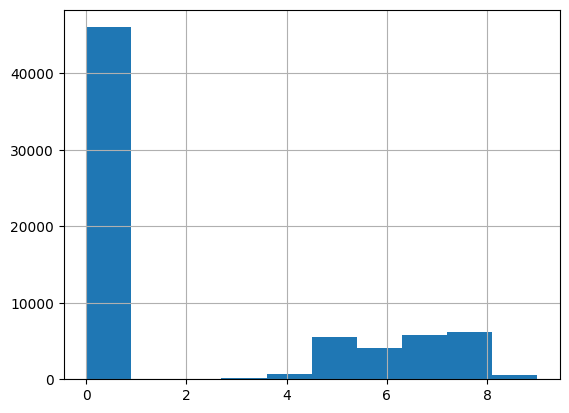

In [84]:
# построим гистограмму по рейтингу
df['review_score'].hist()

<Axes: >

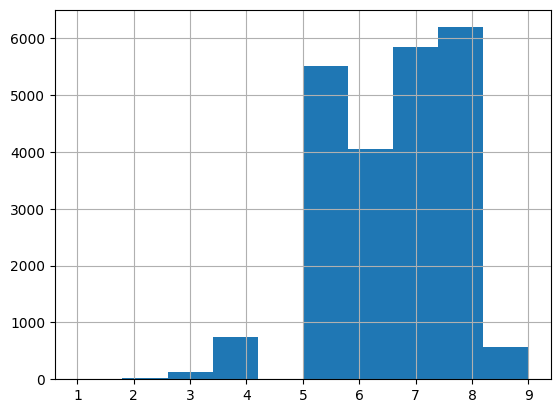

In [85]:
df[df['review_score'] != 0]['review_score'].hist()

`.value_counts()` — один из самых полезных и мощных методов в pandas.

In [86]:
df[df['review_score'] != 0]['review_score'].value_counts()

,count
review_score,
8.0,6192
7.0,5849
5.0,5510
6.0,4049
4.0,750
9.0,573
3.0,125
2.0,25
1.0,4


In [87]:
# посмотрим, сколько бесплатных игр
df['is_free'].value_counts()

,count
is_free,
False,59757
True,9357


<Axes: ylabel='count'>

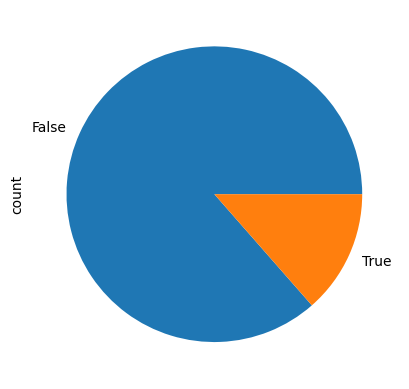

In [88]:
# Визуализируем результат.
# Для этого используем .plot(kind = 'тип графика').
df['is_free'].value_counts().plot(kind = 'pie')

## Работа с пропущенными значениями

В pandas для представления отсутствующих данных используется значение **NaN (Not a Number — не число).**

In [90]:
# во всем DataFrame
df.isna().sum()

,0
name,0
developers_1,6
category_1,0
category_2,0
genre_1,0
genre_2,0
n_achievements,475
platforms,457
is_released,484
release_date,464


In [92]:
# в конкретном столбце
df['is_free'].isna().sum()

np.int64(412)

In [93]:
# удаляем отсутствующие значения во всем DataFrame
df.dropna()

,name,developers_1,category_1,category_2,genre_1,genre_2,n_achievements,platforms,is_released,release_date,total_reviews,total_positive,total_negative,review_score,metacritic,is_free,price_initial (USD)
2,PUIQ: Demons,Giammnn,Single-player,Steam Achievements,Action,Casual,28.0,['windows'],True,2024-02-17,0.0,0.0,0.0,0.0,0.0,False,2.99
3,Project XSTING,Saucy Melon,Single-player,Steam Achievements,Action,Casual,42.0,['windows'],True,2024-01-05,9.0,9.0,0.0,0.0,0.0,False,7.99
6,Manor Madness,Apericot Studio,Single-player,Steam Achievements,Action,Adventure,5.0,"['windows', 'mac', 'linux']",True,2024-01-15,0.0,0.0,0.0,0.0,0.0,True,0.00
7,Fly Hands,Kuryakin,Single-player,Tracked Controller Support,Adventure,Casual,0.0,['windows'],True,2024-03-26,0.0,0.0,0.0,0.0,0.0,False,13.99
11,Tafl PTK,Oak The Wise,Single-player,Multi-player,Casual,Indie,0.0,['windows'],True,2024-02-29,1.0,1.0,0.0,0.0,0.0,False,7.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69520,PIP XL,Cute Hannah's Games,Single-player,Steam Achievements,Adventure,Casual,100.0,['windows'],True,2023-02-08 00:00:00,1.0,1.0,0.0,0.0,0.0,False,1.99
69521,Touchdown Pinball,Super PowerUp Games,Single-player,Steam Achievements,Simulation,-,15.0,['windows'],True,2024-02-09 00:00:00,2.0,2.0,0.0,0.0,0.0,False,2.99
69523,Isle of Swaps,Fuzz Force,Single-player,Steam Achievements,Indie,RPG,29.0,['windows'],True,2024-09-27 00:00:00,72.0,66.0,6.0,8.0,0.0,False,14.99
69524,Goobies,Knifes,Single-player,Steam Achievements,Action,Casual,43.0,['windows'],True,2023-07-14 00:00:00,1442.0,1312.0,130.0,8.0,0.0,False,5.99


In [94]:
# заполняем отсутствующие значения во всем DataFrame
df.fillna('Здесь что-то есть')

,name,developers_1,category_1,category_2,genre_1,genre_2,n_achievements,platforms,is_released,release_date,total_reviews,total_positive,total_negative,review_score,metacritic,is_free,price_initial (USD)
0,勇者の伝説の勇者,ぽけそう,Single-player,Family Sharing,Casual,Indie,0.0,Здесь что-то есть,True,2024-01-04,0.0,0.0,0.0,0.0,0.0,Здесь что-то есть,0.99
1,Light No Fire,Hello Games,Single-player,Multi-player,Action,Adventure,0.0,Здесь что-то есть,False,Not Released,0.0,0.0,0.0,0.0,0.0,Здесь что-то есть,0.0
2,PUIQ: Demons,Giammnn,Single-player,Steam Achievements,Action,Casual,28.0,['windows'],True,2024-02-17,0.0,0.0,0.0,0.0,0.0,False,2.99
3,Project XSTING,Saucy Melon,Single-player,Steam Achievements,Action,Casual,42.0,['windows'],True,2024-01-05,9.0,9.0,0.0,0.0,0.0,False,7.99
4,The Milgram Experiment,Theseus Games,Single-player,-,Adventure,-,0.0,['windows'],False,Not Released,0.0,0.0,0.0,0.0,0.0,False,Здесь что-то есть
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69521,Touchdown Pinball,Super PowerUp Games,Single-player,Steam Achievements,Simulation,-,15.0,['windows'],True,2024-02-09 00:00:00,2.0,2.0,0.0,0.0,0.0,False,2.99
69522,Speed Golf Royale,Mainframe Games,Single-player,Multi-player,Action,Casual,0.0,['windows'],False,Not Released,0.0,0.0,0.0,0.0,0.0,False,Здесь что-то есть
69523,Isle of Swaps,Fuzz Force,Single-player,Steam Achievements,Indie,RPG,29.0,['windows'],True,2024-09-27 00:00:00,72.0,66.0,6.0,8.0,0.0,False,14.99
69524,Goobies,Knifes,Single-player,Steam Achievements,Action,Casual,43.0,['windows'],True,2023-07-14 00:00:00,1442.0,1312.0,130.0,8.0,0.0,False,5.99


In [96]:
# заполнение средними значениями
df['total_positive'] = df['total_positive'].fillna(df['total_positive'].median())
df['total_positive'].isna().sum()

np.int64(0)

## Немного полезностей

Документация библиотеки: [клик](https://pandas.pydata.org/pandas-docs/stable/user_guide/index.html).

Подсказка: если поставить курсор внутрь скобок метода и нажать Tab, появится список подсказок. Если нажать Shift + Tab, откроется подробное описание метода или функции с объяснением параметров.

# Домашнаяя работа


Работаем с файлом **steam_games.csv**.

Выполни задания в ячейках ниже. См. комментарии.

- name — название игры.
- developers — разработчики игры.
- categories — категории игры.
- genres — жанры игры.
- required_age — минимальный возраст.
- n_achievements — количество достижений.
- platforms — доступные платформы.
- is_released — статус выпуска.
- release_date — дата выхода.
- additional_content — дополнительный контент.
- total_reviews — общее число отзывов.
- total_positive — положительные отзывы.
- total_negative — отрицательные отзывы.
- review_score — оценка на основе отзывов.
- metacritic — оценка Metacritic.
- is_free — указание на то, бесплатная игра или нет.
- price_initial (USD) — первоначальная цена в USD.

In [ ]:
df = pd.read_csv("steam_games.csv")
df.head(3)

## Основное задание

In [ ]:
# посчитай, сколько в сумме стоят все игры


In [ ]:
# посчитай средний рейтинг metacritic


In [ ]:
# посчитай средний рейтинг пользователей


In [ ]:
# найди максимальное количество достижений в игре


In [ ]:
# Построй точечный график по признакам review_score и price_initial (USD).
# Видны ли закономерности? Если да, то какие? Запиши ответ в текстовой ячейке.


In [ ]:
# Построй горизонтальную столбчатую диаграмму для признака platforms. Используй .value_counts().


In [ ]:
# Добавь в DataFrame столбец take_my_money со значениями 1 если игра имеет рейтинг > 8.
# Подсказка: удобнее всего это сделать через df[feature_name].apply(lambda x: ...).


## Задание на дополнительную оценку

In [ ]:
# Выведи количество строк и количество столбцов в датасете через пробел.


In [ ]:
# В каких столбцах пропущенных значений больше 470? Выведи список в столбик (только названия признаков).


In [ ]:
# Какие игры в среднем стоят дороже: с рейтингом 5 или с рейтингом 7?


In [ ]:
# Можно ли сказать, что если игра бесплатная, то у нее лучше рейтинг? Ответ объясни.


In [ ]:
# Какой процент игр еще не выпустили в релиз? Ответ округли до двух знаков после запятой.


# Часть 2 (Занятие 6)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Самостоятельная практика

Загрузи файл данных `positions.csv`.

В нём содержится информация о сотрудниках компании company_name, основанной в 2012 году. В 2020 году компания провела масштабный набор сотрудников.

Тебе предстоит выполнить несколько заданий. **Результаты заноси в тест в Информатиксе.**

In [98]:
df = pd.read_csv("positions.csv")
df

,Имя,Должность,Опыт (лет),Зарплата (USD),Удалёнка,В компании с 2020
0,Никита,Data Scientist,1,76000.0,True,False
1,Юлия,Аналитик данных,4,116000.0,True,False
2,Юлия,Data Engineer,4,88000.0,True,False
3,Алексей,ML Researcher,10,119000.0,False,True
4,Алексей,Senior Data Scientist,7,84000.0,False,False
...,...,...,...,...,...,...
95,Надежда,Product Analyst,10,119000.0,False,False
96,Ольга,BI Analyst,6,87000.0,True,False
97,Иван,ML Researcher,2,134000.0,True,True
98,Мария,Product Analyst,9,109000.0,True,False


In [ ]:
# Сколько людей имеют опыт более 7 лет?
df['Опыт (лет)']

In [ ]:
# Посчитайте среднюю зарплату в компании.


In [ ]:
# Сколько в компании Алексеев, которые работают на удалёнке?



In [ ]:
# Специалистов какой должности больше всего в компании?


In [ ]:
# Сколько сотрудников получает зарплату выше медианной?
# Для нахождения медианы используй np.median().



In [ ]:
# Для выполнения этого задания тебе придется посчитать сколько людей с каким именем работает в компании.
# Например: 3 Ивана, 4 Юлии, 1 Никита, 1 Олег.

# Найди два самых популярных и два самых редких имени, а затем определи средний опыт работы этих двух групп.
# Например, средний опыт Иванов и Юлий - 4 года, а средний опыт Никит и Олегов - 2 года.

# В ответе запиши два числа через пробел (сначала для самых популярных имен, затем для самых редких).



## Ещё несколько очень полезных инструментов

### Сортировка

In [99]:
df = pd.read_csv("steam_games.csv")
df

,name,developers_1,category_1,category_2,genre_1,genre_2,n_achievements,platforms,is_released,release_date,total_reviews,total_positive,total_negative,review_score,metacritic,is_free,price_initial (USD)
0,勇者の伝説の勇者,ぽけそう,Single-player,Family Sharing,Casual,Indie,0.0,NaN,True,2024-01-04,0.0,0.0,0.0,0.0,0.0,NaN,0.99
1,Light No Fire,Hello Games,Single-player,Multi-player,Action,Adventure,0.0,NaN,False,Not Released,0.0,0.0,0.0,0.0,0.0,NaN,0.00
2,PUIQ: Demons,Giammnn,Single-player,Steam Achievements,Action,Casual,28.0,['windows'],True,2024-02-17,0.0,0.0,0.0,0.0,0.0,False,2.99
3,Project XSTING,Saucy Melon,Single-player,Steam Achievements,Action,Casual,42.0,['windows'],True,2024-01-05,9.0,9.0,0.0,0.0,0.0,False,7.99
4,The Milgram Experiment,Theseus Games,Single-player,-,Adventure,-,0.0,['windows'],False,Not Released,0.0,0.0,0.0,0.0,0.0,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69521,Touchdown Pinball,Super PowerUp Games,Single-player,Steam Achievements,Simulation,-,15.0,['windows'],True,2024-02-09 00:00:00,2.0,2.0,0.0,0.0,0.0,False,2.99
69522,Speed Golf Royale,Mainframe Games,Single-player,Multi-player,Action,Casual,0.0,['windows'],False,Not Released,0.0,0.0,0.0,0.0,0.0,False,NaN
69523,Isle of Swaps,Fuzz Force,Single-player,Steam Achievements,Indie,RPG,29.0,['windows'],True,2024-09-27 00:00:00,72.0,66.0,6.0,8.0,0.0,False,14.99
69524,Goobies,Knifes,Single-player,Steam Achievements,Action,Casual,43.0,['windows'],True,2023-07-14 00:00:00,1442.0,1312.0,130.0,8.0,0.0,False,5.99


Сортировка значений

In [101]:
df.sort_values('release_date', ascending=False).head(10)

,name,developers_1,category_1,category_2,genre_1,genre_2,n_achievements,platforms,is_released,release_date,total_reviews,total_positive,total_negative,review_score,metacritic,is_free,price_initial (USD)
31219,Silent Planet,Vertex Zero,Single-player,Full controller support,Action,Adventure,0.0,['windows'],False,Not Released,0.0,0.0,0.0,0.0,0.0,False,NaN
51469,The Harvest VR,The Harvest VR,Single-player,-,Casual,Free To Play,0.0,['windows'],False,Not Released,0.0,0.0,0.0,0.0,0.0,True,0.0
17842,Herios,Ratel Studio,Single-player,Multi-player,Strategy,-,0.0,"['windows', 'mac']",False,Not Released,0.0,0.0,0.0,0.0,0.0,False,NaN
64742,Avalon: Sacred Crusade,Looting Lizard Studios,Multi-player,MMO,Indie,Massively Multiplayer,0.0,['windows'],False,Not Released,0.0,0.0,0.0,0.0,0.0,False,NaN
17841,ARC Raiders,Embark Studios,Multi-player,Co-op,Action,-,0.0,['windows'],False,Not Released,0.0,0.0,0.0,0.0,0.0,False,NaN
64737,Hexonomy,Starfish Studios,Single-player,Multi-player,Strategy,Early Access,0.0,['windows'],False,Not Released,0.0,0.0,0.0,0.0,0.0,True,0.0
30661,GuanLan Magic,ComNeko,Single-player,-,Action,Casual,0.0,['windows'],False,Not Released,0.0,0.0,0.0,0.0,0.0,False,NaN
53077,Postmaster Legacy,Crunchy Sushi,Single-player,Steam Achievements,Action,Adventure,0.0,['windows'],False,Not Released,0.0,0.0,0.0,0.0,0.0,False,NaN
64730,Path To Etinway,Dan Kim Nguyen,Single-player,Steam Achievements,Action,Adventure,0.0,['windows'],False,Not Released,0.0,0.0,0.0,0.0,0.0,False,NaN
64729,I wish Michael Phantomino were here,surikovdanya,Single-player,Multi-player,Casual,Indie,0.0,['windows'],False,Not Released,0.0,0.0,0.0,0.0,0.0,False,NaN


In [102]:
df.sort_values('release_date').head(10)

,name,developers_1,category_1,category_2,genre_1,genre_2,n_achievements,platforms,is_released,release_date,total_reviews,total_positive,total_negative,review_score,metacritic,is_free,price_initial (USD)
24650,Carmageddon Max Pack,Stainless Games Ltd,Single-player,Multi-player,Action,Indie,0.0,['windows'],True,1997-06-30 00:00:00,252.0,218.0,34.0,8.0,0.0,False,9.99
25774,Gothic 1,Piranha Bytes,Single-player,Family Sharing,Action,RPG,0.0,['windows'],True,2001-03-15 00:00:00,2360.0,1978.0,382.0,8.0,81.0,False,19.99
25652,Geneforge 1,Spiderweb Software,Single-player,Family Sharing,Strategy,RPG,0.0,['windows'],True,2001-12-01 00:00:00,279.0,261.0,18.0,8.0,0.0,False,19.99
25653,Geneforge 2,Spiderweb Software,Single-player,Family Sharing,Strategy,RPG,0.0,['windows'],True,2003-07-01 00:00:00,58.0,54.0,4.0,8.0,0.0,False,19.99
25654,Geneforge 3,Spiderweb Software,Single-player,Family Sharing,Strategy,RPG,0.0,['windows'],True,2005-04-01 00:00:00,38.0,34.0,4.0,7.0,0.0,False,19.99
54181,Darwinia,Introversion Software,Single-player,Full controller support,Indie,Strategy,0.0,"['windows', 'mac', 'linux']",True,2005-07-14 00:00:00,548.0,455.0,93.0,8.0,84.0,False,9.99
25923,Gothic II: Gold Edition,Piranha Bytes,Single-player,Family Sharing,Action,RPG,0.0,['windows'],True,2005-11-29 00:00:00,2140.0,1867.0,273.0,8.0,79.0,False,19.99
63216,Insaniquarium Deluxe,"PopCap Games, Inc.",Single-player,Family Sharing,Casual,-,0.0,['windows'],True,2006-08-30 00:00:00,4017.0,3921.0,96.0,9.0,0.0,False,4.99
55304,Call of Duty® 2,Infinity Ward,Single-player,Multi-player,Action,-,0.0,"['windows', 'mac']",True,2006-10-13 00:00:00,3573.0,3307.0,266.0,8.0,86.0,False,19.99
56628,Dark Messiah of Might & Magic,Arkane Studios,Single-player,Multi-player,Action,RPG,0.0,['windows'],True,2006-10-25 00:00:00,4219.0,3786.0,433.0,8.0,72.0,False,9.99


Сортировка по индексу

In [103]:
df.sort_index().head()

,name,developers_1,category_1,category_2,genre_1,genre_2,n_achievements,platforms,is_released,release_date,total_reviews,total_positive,total_negative,review_score,metacritic,is_free,price_initial (USD)
0,勇者の伝説の勇者,ぽけそう,Single-player,Family Sharing,Casual,Indie,0.0,NaN,True,2024-01-04,0.0,0.0,0.0,0.0,0.0,NaN,0.99
1,Light No Fire,Hello Games,Single-player,Multi-player,Action,Adventure,0.0,NaN,False,Not Released,0.0,0.0,0.0,0.0,0.0,NaN,0.00
2,PUIQ: Demons,Giammnn,Single-player,Steam Achievements,Action,Casual,28.0,['windows'],True,2024-02-17,0.0,0.0,0.0,0.0,0.0,False,2.99
3,Project XSTING,Saucy Melon,Single-player,Steam Achievements,Action,Casual,42.0,['windows'],True,2024-01-05,9.0,9.0,0.0,0.0,0.0,False,7.99
4,The Milgram Experiment,Theseus Games,Single-player,-,Adventure,-,0.0,['windows'],False,Not Released,0.0,0.0,0.0,0.0,0.0,False,NaN


### Агрегирование данных и групповые операции

В анализе данных часто используется группировка — разделение датасета на группы с последующим вычислением агрегатных показателей, таких как среднее или сумма, для каждой группы.

**Группировки**

In [108]:
list(df.groupby(['platforms']))

[(("['linux']",),
                              name      developers_1     category_1  \
  1803                  CUPRUM2929           Vaslabs  Single-player   
  7026                 CommunityUs       CommunityUs  Single-player   
  22633        CINEVEO - VR Cinema    Mindprobe Labs  Single-player   
  35739                        Lif                MZ  Single-player   
  40765  Swinario Super Bros. Play        Maxtrigger              -   
  65025                       Omni  JackHasaKeyboard  Single-player   
  
                      category_2     genre_1     genre_2  n_achievements  \
  1803   Full controller support   Adventure         RPG             0.0   
  7026            Steam Workshop   Adventure      Casual             0.0   
  22633             Multi-player  Simulation           -             0.0   
  35739           Family Sharing      Action       Indie             0.0   
  40765                        -   Adventure           -             0.0   
  65025                   

In [109]:
df.groupby(['platforms']).mean(numeric_only=True)

,n_achievements,total_reviews,total_positive,total_negative,review_score,metacritic,price_initial (USD)
platforms,,,,,,,
['linux'],0.000000,8.500000,3.333333,5.166667,0.666667,0.000000,11.660000
"['mac', 'linux']",0.000000,63.000000,53.000000,10.000000,8.000000,0.000000,4.990000
['mac'],4.350000,9.238095,5.571429,3.666667,0.238095,0.000000,18.991818
"['windows', 'linux']",14.735924,740.178727,645.747021,96.711287,2.209607,1.855268,6.349744
"['windows', 'mac', 'linux']",23.657906,831.387234,774.940534,62.938059,3.745274,6.738099,11.858006
"['windows', 'mac']",14.453422,643.465403,590.290659,56.930538,2.912782,4.384166,7.777432
['windows'],15.234061,308.855845,265.174296,44.483250,1.888899,1.894327,7.566591


In [110]:
# Чаще всего нас интересует только один столбец.
df.groupby(['platforms']).mean(numeric_only=True)['total_reviews']

,total_reviews
platforms,
['linux'],8.500000
"['mac', 'linux']",63.000000
['mac'],9.238095
"['windows', 'linux']",740.178727
"['windows', 'mac', 'linux']",831.387234
"['windows', 'mac']",643.465403
['windows'],308.855845


**Собственные функции**

In [111]:
# Напиши свою функцию, например, для вычисления разности среднего и медианного значений (по модулю).
def m_m(arr):
  arr = arr.dropna()
  return np.abs(np.median(arr) - arr.mean())

In [112]:
# Если интересен только один столбец, не обязательно группиповать весь df.
df['price_initial (USD)'].groupby(df['platforms']).agg(m_m)

,price_initial (USD)
platforms,
['linux'],6.670000
"['mac', 'linux']",0.000000
['mac'],4.001818
"['windows', 'linux']",1.359744
"['windows', 'mac', 'linux']",4.868006
"['windows', 'mac']",2.787432
['windows'],2.576591


## Нужно больше практики!

Работаем с файлом **steam_games.csv**.

Визуализируем, анализируем, генерируем.

**Начнем с анализа**

In [113]:
df

,name,developers_1,category_1,category_2,genre_1,genre_2,n_achievements,platforms,is_released,release_date,total_reviews,total_positive,total_negative,review_score,metacritic,is_free,price_initial (USD)
0,勇者の伝説の勇者,ぽけそう,Single-player,Family Sharing,Casual,Indie,0.0,NaN,True,2024-01-04,0.0,0.0,0.0,0.0,0.0,NaN,0.99
1,Light No Fire,Hello Games,Single-player,Multi-player,Action,Adventure,0.0,NaN,False,Not Released,0.0,0.0,0.0,0.0,0.0,NaN,0.00
2,PUIQ: Demons,Giammnn,Single-player,Steam Achievements,Action,Casual,28.0,['windows'],True,2024-02-17,0.0,0.0,0.0,0.0,0.0,False,2.99
3,Project XSTING,Saucy Melon,Single-player,Steam Achievements,Action,Casual,42.0,['windows'],True,2024-01-05,9.0,9.0,0.0,0.0,0.0,False,7.99
4,The Milgram Experiment,Theseus Games,Single-player,-,Adventure,-,0.0,['windows'],False,Not Released,0.0,0.0,0.0,0.0,0.0,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69521,Touchdown Pinball,Super PowerUp Games,Single-player,Steam Achievements,Simulation,-,15.0,['windows'],True,2024-02-09 00:00:00,2.0,2.0,0.0,0.0,0.0,False,2.99
69522,Speed Golf Royale,Mainframe Games,Single-player,Multi-player,Action,Casual,0.0,['windows'],False,Not Released,0.0,0.0,0.0,0.0,0.0,False,NaN
69523,Isle of Swaps,Fuzz Force,Single-player,Steam Achievements,Indie,RPG,29.0,['windows'],True,2024-09-27 00:00:00,72.0,66.0,6.0,8.0,0.0,False,14.99
69524,Goobies,Knifes,Single-player,Steam Achievements,Action,Casual,43.0,['windows'],True,2023-07-14 00:00:00,1442.0,1312.0,130.0,8.0,0.0,False,5.99


In [116]:
# 1. Топ-10 самых популярных игр по количеству положительных отзывов.
# Подсказка: для красивого вывода используй сепаратор.
print(*df.sort_values('total_positive', ascending=False).name.iloc[:10].values, sep='\n')

Counter-Strike 2
Terraria
Tom Clancy's Rainbow Six® Siege
Grand Theft Auto V
HELLDIVERS™ 2
Rust
Baldur's Gate 3
Stardew Valley
Among Us
Phasmophobia


In [ ]:
# 2. Топ-3 самых дорогих в среднем категорий (category_1) игр.


In [ ]:
# 3. В каком жанре (genre_1) в среднем больше всего достижений?


In [ ]:
# 4. Какой % игр выпускается для mac?


In [ ]:
# 5. Какой разработчик выпустил больше всего игр?


In [ ]:
# 6. Какой % игр имеет хотя бы на 10 положительных отзывов больше, чем отрицательных?


In [ ]:
# 7. Сколько игр стоимостью меньше 1$ выпустили в 2023 году?
# Подсказка: используй feature.str.startswith().


# Часть 3 (Занятие 7)

**Сгенерируем пару новых признаков и продолжим анализировать**.

In [ ]:
df

In [ ]:
# 8. Какие признаки можно разделить/изменить, чтобы с ними было удобно работать?


In [ ]:
 #9. Создай новые признаки (из задания 8).

In [ ]:
# 9.1


In [ ]:
# 9.2


In [ ]:
# 10. В каком месяце чаще всего выпускают игры?


In [ ]:
# 11. Какая игра из тех, что вышли весной и поддерживают все платформы, имеет наибольшее количество отзывов?


In [ ]:
# 12. Каких игр поддерживающих все платформы и вышедших летом было больше: платных или бесплатных?


**Пора что-нибудь нарисовать!**

Не забывайте: графики должны быть понятными!

Подсказка, как делать графики прямо из pandas: [тык](https://pandas.pydata.org/docs/user_guide/visualization.html).

In [ ]:
# 13. Изобрази распределение игр из задания 12 с помощью круговой диаграммы.


In [ ]:
# 14. Изобрази распределение категорий игр из задания 2 с помощью столбчатой диаграммы: игры каких категорий сколько стоят в среднем?


In [ ]:
# 15. Построй гистограммы для четырех самых популярных жанров (genre_1) по признаку стоимость. Учитывать только игры дешевле 30$.


In [ ]:
# 16. Построй точечный график зависимости количества достижений от года выпуска игры. Есть ли закономерности?


**Еще немного генерации**

In [ ]:
# 17*. Какой признак/признаки ты бы добавил? Почему?


In [ ]:
# 18*. Добавь его/их и визуализируй (если этот признак можно получить из уже имеющихся).
